# V2_4 · Paul — Mouse haematopoiesis MARS-seq (multi-branch downstream)

**Data**: `paul_cds.h5ad` is the post-pipeline CDS from the paper authors and
already contains:
- 2699 cells × 3004 genes (UMI, lymphoid cells removed)
- `obs['cluster']` (1–18; original Amit 19-cluster numbering)
- `obs['State']` (1–11; aligned with the paper's Fig 16A — root = 10,
  six terminal branches = 1 / 3 / 4 / 6 / 11 / 9)
- DDRTree projection in `obsm['X_dr']` and the principal-graph state in
  `uns['monocle2']['ddrtree']`
- `obs['Pseudotime']`

Re-running DDRTree would re-randomise State numbering and break the
downstream `branches = [1, 3, 4, 6, 11, 9]` calls, so we start from the
stored projection and only re-anchor pseudotime.

**This notebook**:
1. Load the finished CDS and re-anchor pseudotime to state 10
2. Add the fine cell-type column `cell_type2`
3. Trajectory overview via `plot_complex_cell_trajectory`
4. State × cell_type2 distribution heatmap
5. Lineage + stemness scoring against the gene set bundled in `paul_gene_set.json`
6. `plot_multiple_branches_pseudotime` and `plot_multiple_branches_heatmap`
7. BEAM at `branch_point = 1` and a branched heatmap

In [1]:
import numpy as np
import pandas as pd
from pheatmap import pheatmap

from monocle2py import (
    beam,
    estimate_size_factors,
    load_paul_cds,
    load_paul_gene_set,
    order_cells,
    plot_complex_cell_trajectory,
    plot_genes_branched_heatmap,
    plot_multiple_branches_heatmap,
    plot_multiple_branches_pseudotime,
)
from monocle2py._uns import set_disp_fit_info

In [2]:
cds = load_paul_cds()
print('paul_cds:', cds.shape)
print('pData columns:', list(cds.obs.columns))
print('State table:')
cds.obs['State'].astype(int).value_counts().sort_index()

paul_cds: (2699, 3004)
pData columns: ['Seq_batch_ID', 'Amp_batch_ID', 'well_coordinates', 'Mouse_ID', 'Plate_ID', 'Batch_desc', 'Pool_barcode', 'Cell_barcode', 'RMT_sequence', 'Number_of_cells', 'CD34_measurement', 'FcgR3_measurement', 'cluster', 'Size_Factor', 'cell_type', 'Pseudotime', 'State']
State table:


State
1      589
3       92
4      120
6      357
7      138
9     1038
10     284
11      81
Name: count, dtype: int64

## 1. Re-anchor pseudotime to state 10 (paper root)

`order_cells(root_state=10)` re-runs the cell-MST DFS rooted at the State that
matches the paper's Fig 16A root.

In [3]:
estimate_size_factors(cds)
order_cells(cds, root_state=10)
pt = cds.obs['Pseudotime'].to_numpy(float)
print(f'Pseudotime range after re-rooting: [{pt.min():.2f}, {pt.max():.2f}]')

Pseudotime range after re-rooting: [0.00, 20.90]


## 2. Fine cell-type label `cell_type2`

Re-map the 1–18 cluster labels into broader lineages.

In [4]:
cluster_to_label = {
    1: 'Ery', 2: 'Ery', 3: 'Ery', 4: 'Ery', 5: 'Ery', 6: 'Ery',
    7: 'MP/EP', 8: 'MK', 9: 'GMP', 10: 'GMP',
    11: 'DC',
    12: 'B', 13: 'B', 14: 'M', 15: 'M',
    16: 'N', 17: 'N', 18: 'E',
}
cds.obs['cell_type2'] = (
    cds.obs['cluster'].astype(int).map(cluster_to_label).astype('category')
)
cds.obs['cell_type2'].value_counts()

cell_type2
Ery      1095
M         673
N         350
GMP       216
MP/EP     167
B          91
MK         68
DC         30
E           9
Name: count, dtype: int64

## 3. Trajectory overview

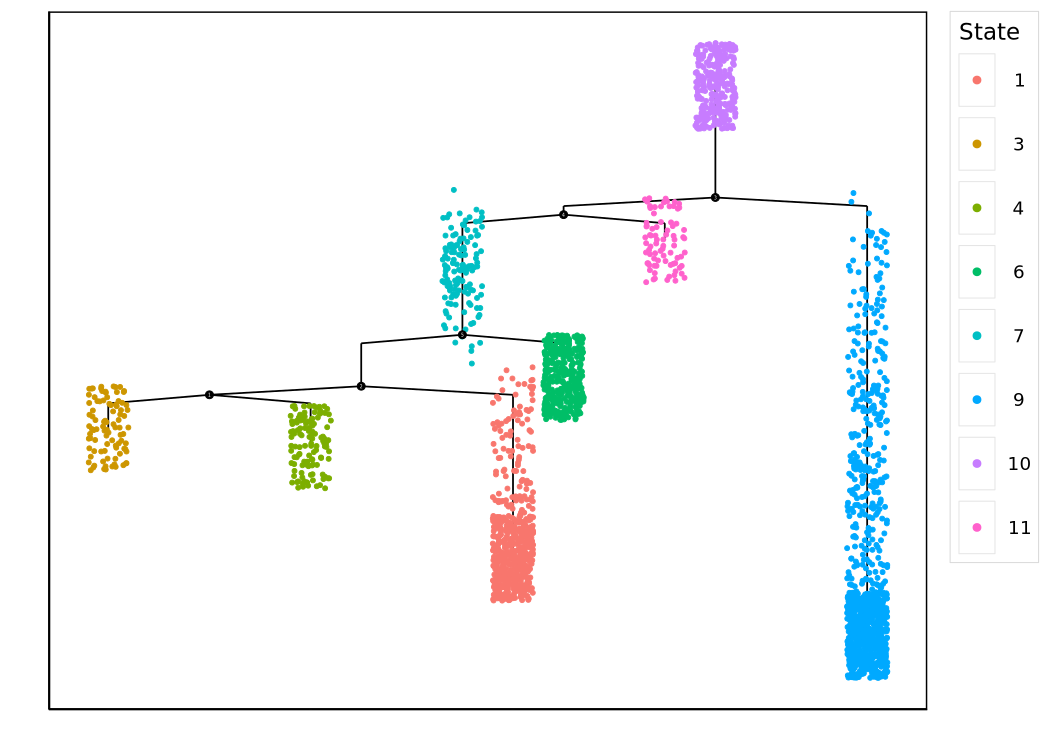

In [5]:
plot_complex_cell_trajectory(
    cds, color_by='State', show_branch_points=True,
    cell_size=0.5, cell_link_size=0.3, root_states=[10],
)

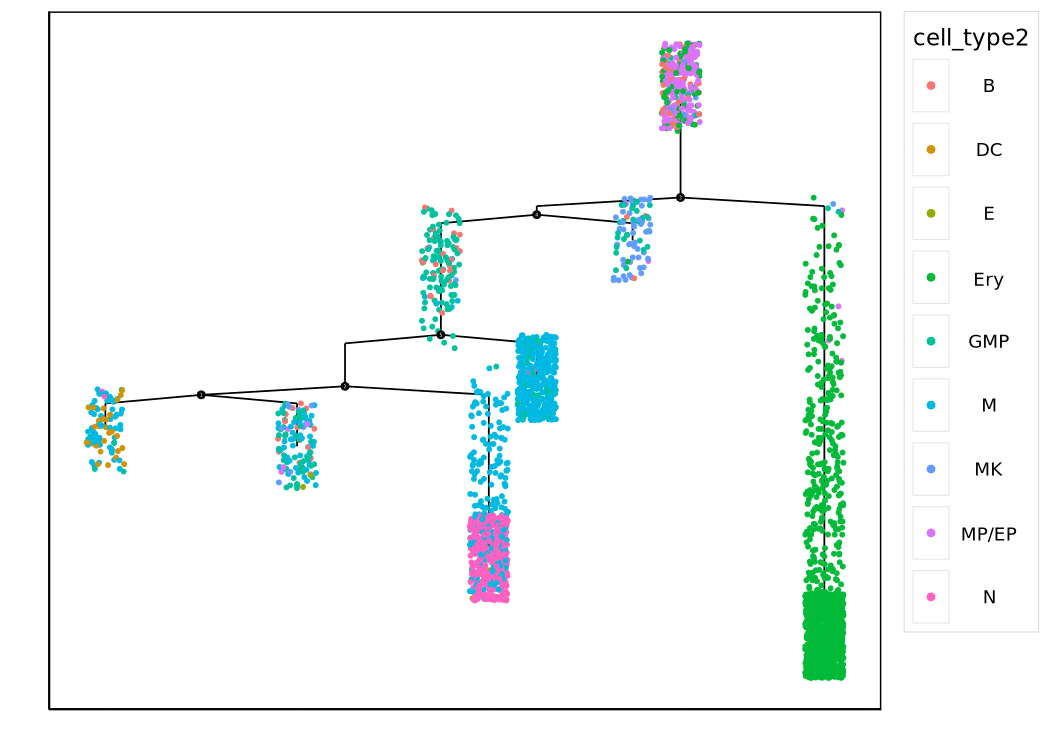

In [6]:
plot_complex_cell_trajectory(
    cds, color_by='cell_type2', show_branch_points=True,
    cell_size=0.5, cell_link_size=0.3, root_states=[10],
)

## 4. State × cell_type2 distribution heatmap

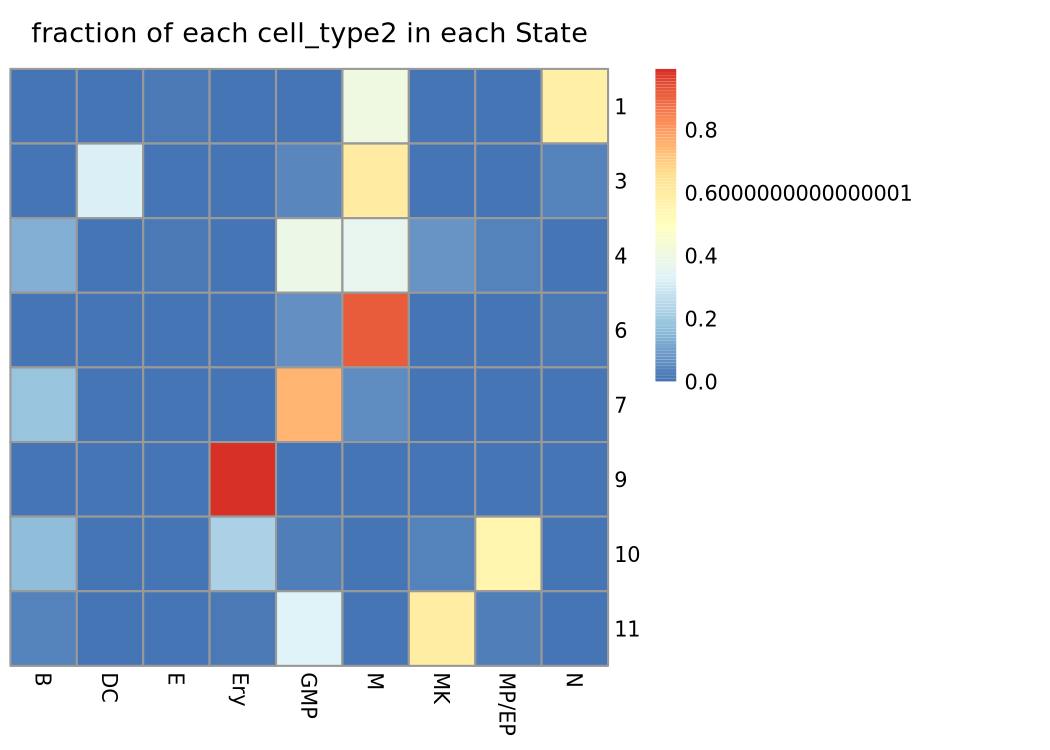

In [7]:
state_cluster = pd.crosstab(
    cds.obs['State'].astype(int), cds.obs['cell_type2'],
)
frac = state_cluster.div(state_cluster.sum(axis=1), axis=0)
pheatmap(
    frac.to_numpy(), cluster_rows=False, cluster_cols=False,
    labels_row=[str(s) for s in frac.index],
    labels_col=list(frac.columns),
    main='fraction of each cell_type2 in each State',
)

## 5. Lineage + stemness scoring

`paul_gene_set.json` carries three lists harvested from the original V1 BEAM
+ calILRs analysis:
- `positive_score_genes` — Ery/Meg-lineage activated genes
- `negtive_score_genes` — opposing (GMP) lineage activated genes
- `all_down_valid` — stemness candidates that drop along pseudotime in both branches

In [8]:
gene_set = load_paul_gene_set()
pos = sorted(set(gene_set['positive_score_genes']) & set(cds.var_names))
neg = sorted(set(gene_set['negtive_score_genes']) & set(cds.var_names))
stem = sorted(set(gene_set['all_down_valid']) & set(cds.var_names))
print(f'positive: {len(pos)}  negative: {len(neg)}  stemness: {len(stem)}')

X = cds.X.toarray() if hasattr(cds.X, 'toarray') else np.asarray(cds.X)
pos_idx = cds.var_names.get_indexer(pos)
neg_idx = cds.var_names.get_indexer(neg)
ery_meg = X[:, pos_idx].mean(axis=1) - X[:, neg_idx].mean(axis=1)
cds.obs['ery_meg_lineage_score'] = -ery_meg  # +ve toward Ery/Meg

tpm = X / X.sum(axis=1, keepdims=True) * 1e6
stem_idx = cds.var_names.get_indexer(stem)
cds.obs['cell_stemness_score'] = np.log2(tpm[:, stem_idx].mean(axis=1) + 1e-6)
cds.obs[['ery_meg_lineage_score', 'cell_stemness_score']].describe()

positive: 87  negative: 51  stemness: 19


,ery_meg_lineage_score,cell_stemness_score
count,2699.000000,2699.000000
mean,0.386655,-3.929776
std,1.249470,12.795720
min,-3.016227,-19.931569
25%,-0.507099,-19.931569
50%,0.216362,5.093366
75%,1.300203,6.464291
max,4.463151,10.486776


/scratch/groups/xiaojie/nianping_scratch/Test_Monocle2/monocle2py/monocle2py/plotting/trajectory.py:450: RuntimeWarning: invalid value encountered in log10
  cell_df["__log_color"] = np.log10(


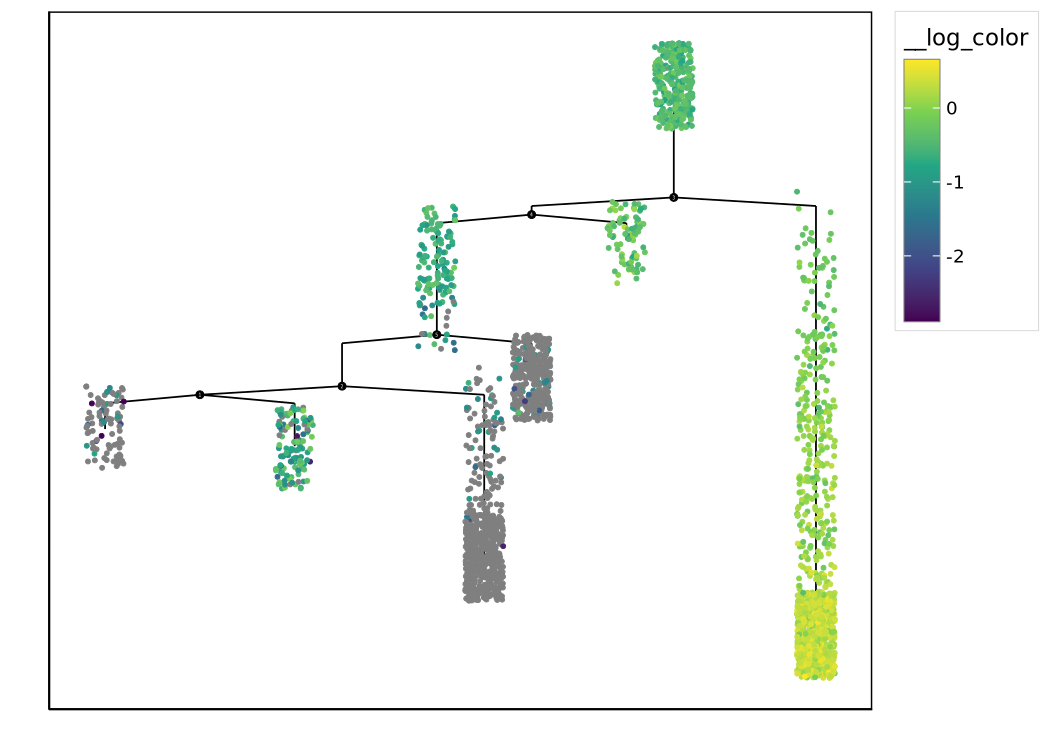

In [9]:
plot_complex_cell_trajectory(
    cds, color_by='ery_meg_lineage_score',
    show_branch_points=True, cell_size=0.5,
    cell_link_size=0.3, root_states=[10],
)

/scratch/groups/xiaojie/nianping_scratch/Test_Monocle2/monocle2py/monocle2py/plotting/trajectory.py:450: RuntimeWarning: invalid value encountered in log10
  cell_df["__log_color"] = np.log10(


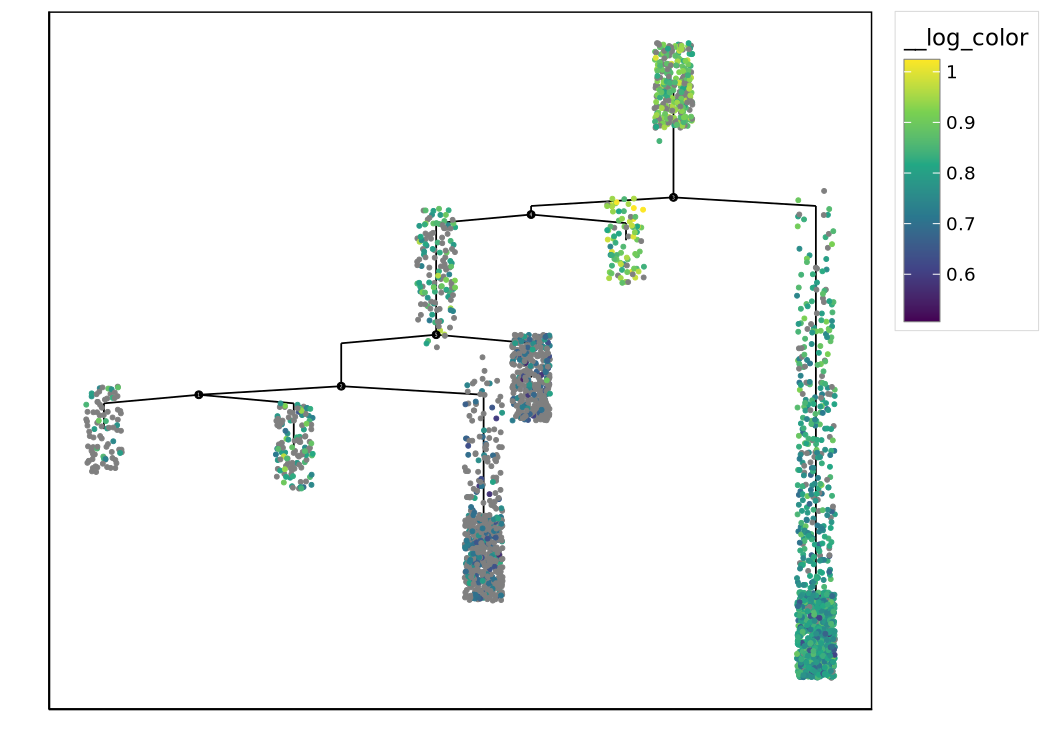

In [10]:
plot_complex_cell_trajectory(
    cds, color_by='cell_stemness_score',
    show_branch_points=True, cell_size=0.5,
    cell_link_size=0.3, root_states=[10],
)

## 6. Multi-branch visualisation across the terminal branches

Paper Fig 16A labels States 1 / 3 / 4 / 6 / 11 / 9 as Neu / DC / Baso / Mono / MK / Ery.
Python `order_cells` re-derives states from the MST of the principal graph, so
the State numbering differs from R's (the underlying topology is the same).
We intersect the paper's labels with the States that are actually present and
plot whatever survives.

Paper branches kept after Python re-ordering: [(1, 'Neu'), (3, 'DC'), (4, 'Baso'), (6, 'Mono'), (11, 'MK'), (9, 'Ery')]


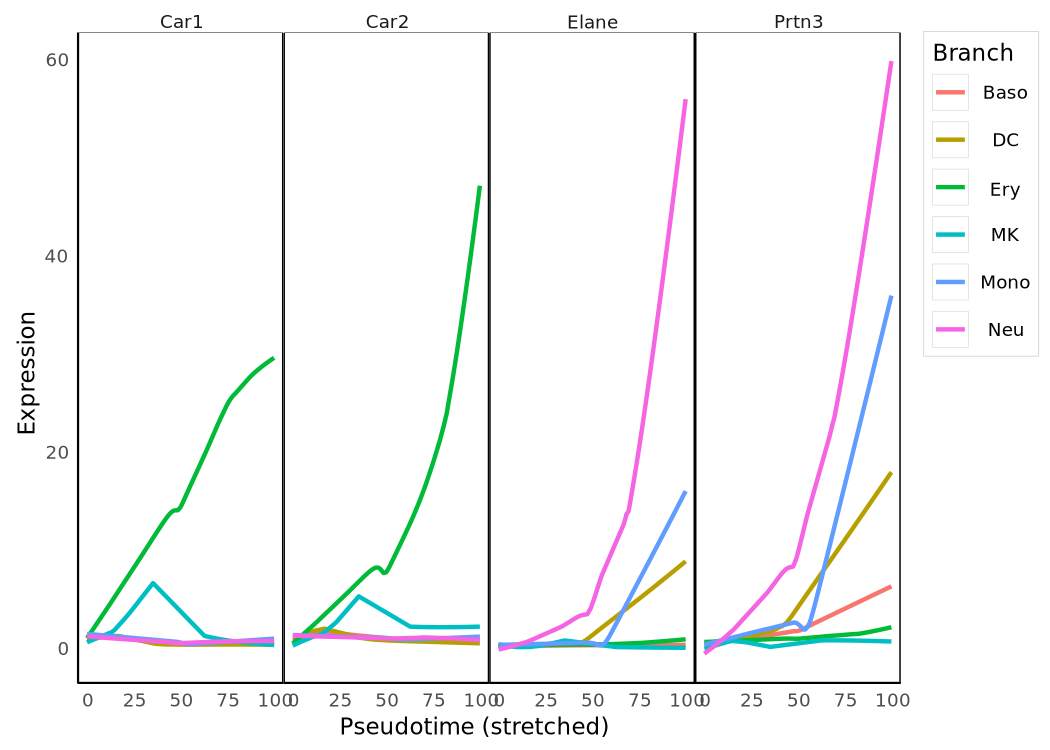

In [11]:
paper_branches = [1, 3, 4, 6, 11, 9]
paper_names = ['Neu', 'DC', 'Baso', 'Mono', 'MK', 'Ery']
available = set(cds.obs['State'].astype(int).unique().tolist())
keep = [(b, n) for b, n in zip(paper_branches, paper_names) if b in available]
branches_paul = [b for b, _ in keep]
branch_names = [n for _, n in keep]
print('Paper branches kept after Python re-ordering:',
      list(zip(branches_paul, branch_names)))

marker_short = ['Car1', 'Elane', 'Car2', 'Prtn3']
marker_genes = cds.var_names[
    cds.var['gene_short_name'].isin(marker_short)
].tolist() if 'gene_short_name' in cds.var else marker_short
marker_genes = [g for g in marker_genes if g in cds.var_names]
plot_multiple_branches_pseudotime(
    cds[:, marker_genes], branches=branches_paul,
    branches_name=branch_names, color_by='Branch', ncol=4,
)

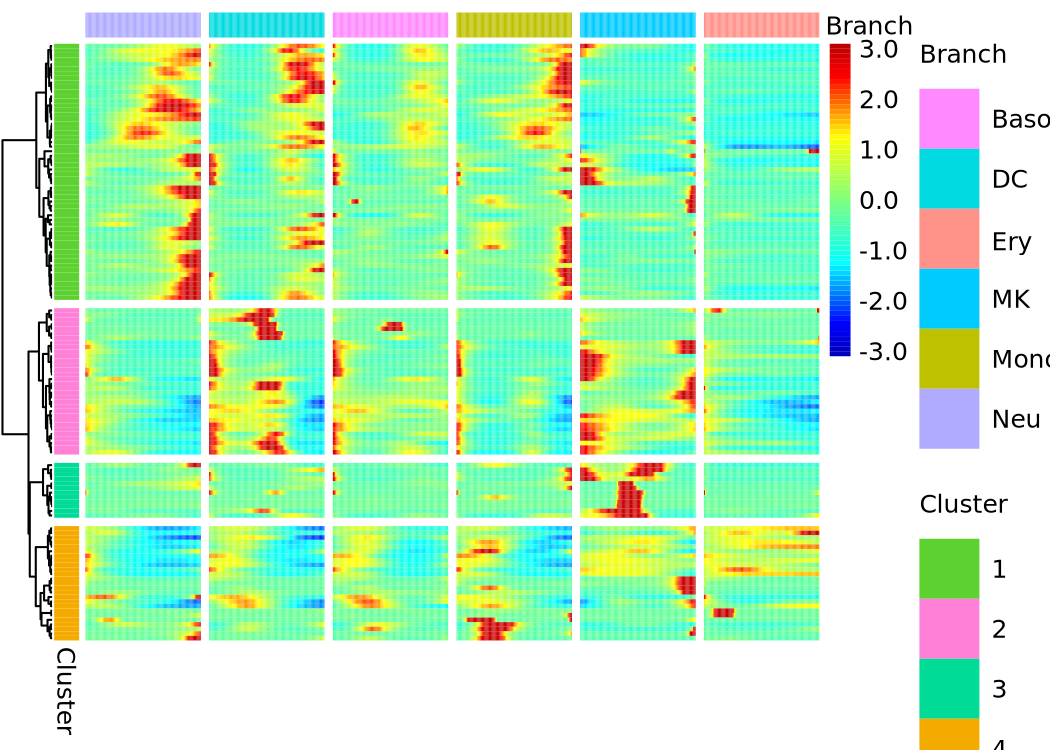

In [12]:
score_genes = sorted(set(pos) | set(neg))
plot_multiple_branches_heatmap(
    cds[:, score_genes], branches=branches_paul,
    branches_name=branch_names, num_clusters=4,
    show_rownames=False,
)

## 7. BEAM at `branch_point = 1`

Branch-dependent gene test on the first branch point (Ery/Meg vs other lineages).
We restrict to the top-expressed 300 genes for speed; the V2_2 lung notebook runs
BEAM on the full panel.

In [13]:
expr_count = (X > 0).sum(axis=0)
panel_idx = np.argsort(-expr_count)[:300]
panel_genes = cds.var_names[panel_idx].tolist()
panel = cds[:, panel_genes].copy()
panel.uns['monocle2'] = dict(cds.uns['monocle2'])

def _disp_func(q):
    return 0.05 + 1.0 / np.asarray(q, dtype=float)
set_disp_fit_info(
    panel,
    {'disp_func': _disp_func,
     'coefficients': {'asymptDisp': 0.05, 'extraPois': 1.0},
     'disp_table': pd.DataFrame()},
    name='blind',
)
beam_res = beam(panel, branch_point=1).sort_values('qval')
print('qval < 1e-4:', int((beam_res['qval'] < 1e-4).sum()))
beam_res[['gene_short_name', 'pval', 'qval']].head(15)

qval < 1e-4: 11


,gene_short_name,pval,qval
gene_id,,,
Cst3,Cst3,7.777468e-51,2.333241e-48
Srgn,Srgn,1.009756e-22,1.514634e-20
Actb,Actb,2.152239e-21,2.152239e-19
Elane,Elane,2.340144e-15,1.755108e-13
Atpif1,Atpif1,4.274838e-08,2.564903e-06
Eef1g,Eef1g,7.108972e-08,3.554486e-06
Hsp90ab1,Hsp90ab1,3.513359e-07,1.505725e-05
Lrrc58,Lrrc58,4.994375e-07,1.872890e-05
Calr,Calr,9.908134e-07,3.302711e-05


In [14]:
top_genes = beam_res[beam_res['qval'] < 1e-4].index.tolist()
if len(top_genes) >= 5:
    plot_genes_branched_heatmap(
        cds[:, top_genes], branch_point=1,
        num_clusters=4, use_gene_short_name=True,
        show_rownames=False,
    )
else:
    print('Fewer than 5 BEAM hits at qval<1e-4 — skipping heatmap.')